# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Anneliese Tarzian
* Username: atarzian
* Student number: S6199984
* Group (AS1, etc.): AS1

-----

In [1]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

$$ \sigma_{g} ^2 = \left( \frac{\delta g}{\delta L} \right)^2 \sigma_{L} ^2 + \left( \frac{\delta g}{\delta T} \right)^2 \sigma_{T} ^2 $$

In [2]:
import numpy as np
from numpy import pi

# The length L in meters and period T in seconds
L_mean = 1.00     
L_sigma = 0.01    
T_mean = 2.01      
T_sigma = 0.02     

# The best estimate of g using the mean values
g_mean_taylor = (4 * pi**2 * L_mean) / (T_mean**2)

# The relative errors
rel_sigma_L = L_sigma / L_mean
rel_sigma_T = T_sigma / T_mean

# Finding the relative error and absolute error of g using the formula
rel_sigma_g = (rel_sigma_L**2 + 4 * (rel_sigma_T**2))**0.5
g_sigma_taylor = g_mean_taylor * rel_sigma_g

print("The Taylor expansion of first-order is:")
print(f"g = {g_mean_taylor:.4f} +/- {g_sigma_taylor:.4f} m/s^2")

# Monte Carlo samples
N = 100000 

L = np.random.normal(loc=L_mean, scale=L_sigma, size=N)
T = np.random.normal(loc=T_mean, scale=T_sigma, size=N)

# Calculating g for each pair of lenght and time
g = (4 * pi**2 * L) / (T**2)

# Computing the mean and error of g
g_mean_MC = np.mean(g)  
g_sigma_MC = np.std(g)  

print()
print("The Monte Carlo error propagation is:")
print(f"g = {g_mean_MC:.4f} +/- {g_sigma_MC:.4f} m/s^2")

The Taylor expansion of first-order is:
g = 9.7716 +/- 0.2176 m/s^2

The Monte Carlo error propagation is:
g = 9.7755 +/- 0.2174 m/s^2


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 4

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [4]:
import cmath
import numpy as np

# Getting the input from user (as strings first)
a = eval(input("Enter coefficient a: "))
b = eval(input("Enter coefficient b: "))
c = eval(input("Enter coefficient c: "))

if a == 0:
    print("This is not a quadratic equation (a can't be 0)!!!")

# Printing the equation
print(f"The equation is {a}x^2 + {b}x + {c} = 0")

# Calculating the discriminant
d = b**2 - 4*a*c

# Finding the roots, even the complex ones
x1 = ((-b) + cmath.sqrt(d)) / (2*a)
x2 = ((-b) - cmath.sqrt(d)) / (2*a)

# Printing the results
print("The roots are x1 =", x1, "and x2 =", x2)

# Verifing f(x) = 0 for both roots
# If the value is smaller than 1e-12, then it is within numerical precision.
# This means that if we plug in the roots in the equation the result is technically 0.
fx1 = int(abs((a * x1**2) + (b * x1) + c))
fx2 = int(abs((a * x2**2) + (b * x2) + c))

if fx1 == 0 and fx2 == 0:
    print("All good the function is ok and f(x1) = f(x2) = 0")
else:
    print("Oh no... something is wrong...")

Enter coefficient a:  1
Enter coefficient b:  1
Enter coefficient c:  1


The equation is 1x^2 + 1x + 1 = 0
The roots are x1 = (-0.5+0.8660254037844386j) and x2 = (-0.5-0.8660254037844386j)
All good the function is ok and f(x1) = f(x2) = 0


In [5]:
# Leave unaltered
totalpoints += 4
currentpoints += 4

<div class='alert alert-info'>
    <b>Feedback</b> <br>
    You can use numpy for the complex roots calculations
</div>

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

In [6]:
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from scipy.integrate import quad

def gauss(x, A, x0, sigma, z0):
    return (A * np.exp((-((x-x0)**2)) / (2 * (sigma**2))) + z0)

# I tried to make "A" as name for the variable, but it would consider it any constant and not a variable.
# That is the reason I changed the name to avar, from a variable.
# Getting the input from user
avar = eval(input("Enter a value for the amplitude: "))  
x0 = eval(input("Enter a value for the peak center: "))
sigma = eval(input("Enter a value for the width: "))
z0 = eval(input("Enter a value for the offset: "))
a = eval(input("Enter a value for the lower integration limit: "))
b = eval(input("Enter a value for the upper integration limit: "))

# Creating the Gaussian curve and finding the area between the two limits
x = np.linspace(-10, 10, 200) 
y = gauss(x, avar, x0, sigma, z0)
area, error = quad(gauss, a, b, args=(avar, x0, sigma, z0))
print(f"The value for the integral between 0 & 2.5: {area:.2f}")

# Verifing if the two methods of finding the area will give the same result
area_inf, error_inf = quad(gauss, -(np.inf), np.inf, args=(avar, x0, sigma, z0))
area_total = avar * sigma * ((2*pi)**0.5)
print(f"The value for the integral f0r infinity: {area_inf:.6f}")
print(f"The value for the total area using the given formula: {area_total:.6f}")

# We can see the value is the same, but here is the verification
diff = int(abs(area_inf - area_total))

if diff == 0:
    print(f"Yes, the difference is {diff:.1f}, so the values are the same")
else:
    print("Oh no... something is wrong...")

Enter a value for the amplitude:  1
Enter a value for the peak center:  0
Enter a value for the width:  2
Enter a value for the offset:  0
Enter a value for the lower integration limit:  0
Enter a value for the upper integration limit:  2.5


The value for the integral between 0 & 2.5: 1.98
The value for the integral f0r infinity: 5.013257
The value for the total area using the given formula: 5.013257
Yes, the difference is 0.0, so the values are the same


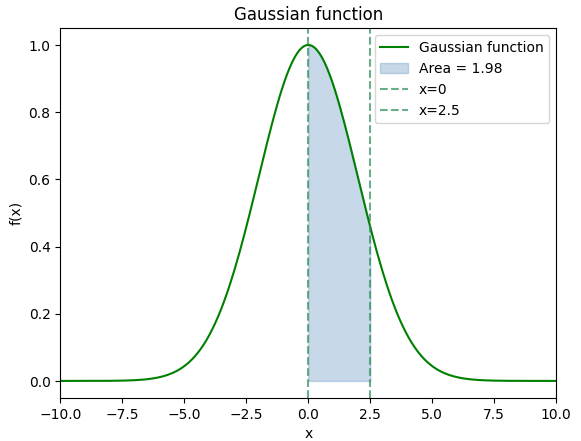

In [7]:
# https://github.com/atarzian-star/PROGNUM-repo/blob/main/Task4/gaussarea.py

In [8]:
# Leave unaltered
totalpoints += 6
currentpoints += 6

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

In [7]:
import numpy as np
from numpy import sin, cos, exp, pi
from scipy.integrate import quad

# Making the function that evaluates functions
def f_eval(expression, x):
    # Make x and expression available globally for eval
    global current_x, expression_global
    current_x = x
    expression_global = expression
    
    try:
        result = eval(expression_global)
        return result
    except NameError:
        print("Error: Unknown function. Use only sin(x), cos(x), exp(x), pi, x")
        print("Make sure to use x as the variable!")
        raise
    except SyntaxError:
        print("Error: Syntax wrong! Check for (), operators etc.")
        raise
    except:
        print("Error: Cannot evaluate expression! Try rewriting it again.")
        raise

# The main code
expression = input("Enter function f(x) [sin(x), cos(x), etc]: ")
a = eval(input("Enter lower limit a: "))
b = eval(input("Enter upper limit b: "))

# Using the Monte Carlo method to integrate
N = 10000
x_mc = np.random.uniform(a, b, N)
y_mc = np.zeros(N)

for i in range(N):
    y_mc[i] = f_eval(expression, x_mc[i])

area_mc = (b - a) * np.mean(y_mc)
print(f"Monte Carlo result: {area_mc:.2f}")

# Using the quad function method to integrate
def f_quad(x):
    return f_eval(expression, x)

area_quad, error_quad = quad(f_quad, a, b)
print(f"Quad result: {area_quad:.2f}")

Enter function f(x) [sin(x), cos(x), etc]: x**4 + exp(sin(x) + cos(x))
Enter lower limit a: 0.0
Enter upper limit b: pi
Monte Carlo result: 67.55
Quad result: 68.73


In [4]:
# https://github.com/atarzian-star/PROGNUM-repo/blob/main/Task4/interate_user_function.py

In [11]:
import sympy
from sympy.abc import x

s = "x**4 + exp(sin(x) + cos(x))"
intg = sympy.integrate(s,(x, 0.0, sympy.pi))
I = intg.evalf()
                       
print(f"The integral of {s} is {I}")

The integral of x**4 + exp(sin(x) + cos(x)) is 68.7293227268911


In [12]:
# Leave unaltered
totalpoints += 6
currentpoints += 4

<div class='alert alert-warning'>
    <b>Feedback</b> <br>
    You should use the exact import line we provide so you don't have to type np. each time<br>
    The try except clauses don't work properly, as you can see above
</div>

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

<img src="attachment:14037eb3-1593-4349-8d4a-ae0bd96b6e97.png" alt="HR Diagram" width="600">

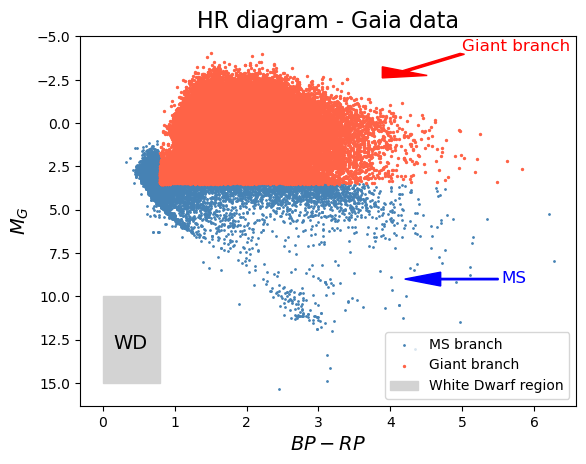

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from matplotlib.patches import Rectangle

# Loading the Gaia data
hdul = fits.open('file:///Users/users/atarzian/PROGNUM-repo/Task4/APOGEE_stars.fits')
data = hdul[1].data
hdul.close()

# Checking the data to retrieve only what we want
good_starflag = (data['STARFLAG'] == 0)
good_aspcapflag = (data['ASPCAPFLAG'] == 0)
good_snr = (data['SNR'] > 10)

# Good parallax precision
parallax_ratio = data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR']
good_parallax = (parallax_ratio > 5)

# No NaN photometry
good_g = ~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])
good_bp = ~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])
good_rp = ~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG'])

# Combining all cuts to be applied
mask = (good_starflag & good_aspcapflag & good_snr & 
        good_parallax & good_g & good_bp & good_rp)

clean_data = data[mask]

# Getting a random 80% of the sample
N = len(clean_data)
indx = np.arange(N)
np.random.shuffle(indx)
N_data = int(N * 0.8)
data_indx = indx[:N_data]

shuffle_data = clean_data[data_indx]

# Getting the colour, magnitude and parallax
bp_rp = shuffle_data['GAIAEDR3_PHOT_BP_MEAN_MAG'] - shuffle_data['GAIAEDR3_PHOT_RP_MEAN_MAG']
g_mag = shuffle_data['GAIAEDR3_PHOT_G_MEAN_MAG']
parallax = shuffle_data['GAIAEDR3_PARALLAX']

# Finding the absolute magnitude using the distance modulus
distance_pc = 1000 / parallax  # transforming from kpc -> pc
MG = g_mag - 5*np.log10(distance_pc) + 5

# Removing any remaining bad values
valid = ~np.isnan(MG) & ~np.isnan(bp_rp) & (MG > -5)
bp_rp_clean = bp_rp[valid]
abs_mag_clean = MG[valid]

# Classifying the stars
colour = bp_rp_clean
mag = abs_mag_clean

giant_mask = (colour > 0.8) & (mag < 3.5)
ms_mask = ~giant_mask 

# Plotting the HR diagram
# Main Sequence (blue)
plt.scatter(bp_rp_clean[ms_mask], abs_mag_clean[ms_mask], 
           color='steelblue', s=1, label='MS branch')

plt.arrow(5.5, 9,
          -0.8, 0,
          width=0.08,
          head_width=0.8,
          head_length=0.5,
          fc='blue',
          ec='blue')

plt.text(5.55,9.2, r'MS', fontsize=12, color='blue')

# Giant branch (red)
plt.scatter(bp_rp_clean[giant_mask], abs_mag_clean[giant_mask], 
           color='tomato', s=2, label='Giant branch')

plt.arrow(5, -4,
          -0.8, 1,
          width=0.08,
          head_width=0.8,
          head_length=0.5,
          fc='red',
          ec='red')

plt.text(5,-4.2, r'Giant branch', fontsize=12, color='red')

# White drwarf region
x = [0, 0.8, 0.8, 0, 0]
y = [10, 10, 15, 15, 10] 
plt.fill(x, y, color='lightgray', label='White Dwarf region')
plt.text(0.15, 13, r'WD', fontsize=14, color='black')

# Formatting
plt.legend()
plt.gca().invert_yaxis()  # magnitude decreases upward
plt.xlabel('$BP - RP$', fontsize=14)
plt.ylabel('$M_G$', fontsize=14)
plt.title('HR diagram - Gaia data', fontsize=16)
plt.show()

In [14]:
# Leave unaltered
totalpoints += 6
currentpoints += 6

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [15]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 26. Student score: 24.  Task Grade = 9.2
